In [57]:
import warnings
warnings.filterwarnings("ignore")

# 📊 Analisi della Mobilità Intelligente - Smart Mobility Traffic Analysis

## 🎯 Obiettivi del progetto

L'obiettivo di questo notebook è analizzare i dati di mobilità urbana per identificare condizioni del traffico, valutare la sicurezza stradale e costruire modelli predittivi legati alla congestione. L'analisi si basa sull'integrazione di più dataset contenenti informazioni su:

- Condizioni stradali e traffico (veicoli, incidenti, situazioni)
- Fattori che influenzano la sicurezza, come condizioni meteo e del manto stradale
- Elementi predittivi per valutare il rischio di incidenti

## 📁 Dataset utilizzati

1. `smart_mobility_dataset.csv`: contiene informazioni di base su traffico e mobilità

L’obiettivo finale sarà quello di costruire una base analitica utile per proposte di miglioramento della viabilità e sicurezza urbana.

In [58]:
#Importiamo le librerie 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler

#Leggiamo il dataset
dataset = pd.read_csv('smart_mobility_dataset.csv')

dataset.head()


,Timestamp,Latitude,Longitude,Vehicle_Count,Traffic_Speed_kmh,Road_Occupancy_%,Traffic_Light_State,Weather_Condition,Accident_Report,Sentiment_Score,Ride_Sharing_Demand,Parking_Availability,Emission_Levels_g_km,Energy_Consumption_L_h,Traffic_Condition
0,2024-03-01 00:00:00,40.842275,-73.703149,205,49.893435,82.652780,Yellow,Clear,0,-0.609199,2,45,450.760055,19.574337,High
1,2024-03-01 00:05:00,40.831119,-73.987354,202,22.383965,45.829298,Green,Clear,0,0.965442,16,1,321.800341,5.385554,High
2,2024-03-01 00:10:00,40.819549,-73.732462,252,46.889699,82.772465,Green,Rain,0,0.289660,16,49,231.152655,10.277477,High
3,2024-03-01 00:15:00,40.725849,-73.980134,37,5.730536,37.695567,Red,Fog,0,-0.271965,66,10,410.384292,29.243279,High
4,2024-03-01 00:20:00,40.813265,-73.961631,64,61.348034,22.313358,Red,Snow,0,-0.797606,3,5,364.466342,16.801459,Low


In [59]:
#Visualizziamo i tipi delle colonne
print(f"{dataset.dtypes}\n")

print("Number of rows: ", dataset.shape[0])
print("Number of columns: ", dataset.shape[1])

Timestamp                  object
Latitude                  float64
Longitude                 float64
Vehicle_Count               int64
Traffic_Speed_kmh         float64
Road_Occupancy_%          float64
Traffic_Light_State        object
Weather_Condition          object
Accident_Report             int64
Sentiment_Score           float64
Ride_Sharing_Demand         int64
Parking_Availability        int64
Emission_Levels_g_km      float64
Energy_Consumption_L_h    float64
Traffic_Condition          object
dtype: object

Number of rows:  5000
Number of columns:  15


In [60]:
# calcolo statistiche descrittive
dataset.describe()

,Latitude,Longitude,Vehicle_Count,Traffic_Speed_kmh,Road_Occupancy_%,Accident_Report,Sentiment_Score,Ride_Sharing_Demand,Parking_Availability,Emission_Levels_g_km,Energy_Consumption_L_h
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,40.749645,-73.847433,153.921200,42.111096,54.748397,0.096000,-0.005652,50.487800,24.613000,272.174927,17.343243
std,0.086123,0.086204,83.523342,21.707720,26.145238,0.294621,0.583790,28.484426,14.532511,130.086372,7.208277
min,40.600016,-73.999987,10.000000,5.002789,10.005031,0.000000,-0.999819,1.000000,0.000000,50.136855,5.003787
25%,40.675403,-73.920281,80.000000,23.195752,32.089653,0.000000,-0.500154,26.000000,12.000000,160.564433,11.098761
50%,40.748875,-73.846058,156.000000,42.191599,54.657297,0.000000,-0.010564,50.000000,24.000000,272.045513,17.153791
75%,40.824735,-73.771685,226.000000,60.751760,77.581720,0.000000,0.500518,75.000000,37.000000,382.242055,23.516595
max,40.899972,-73.700159,299.000000,79.997556,99.999729,1.000000,0.999354,99.000000,49.000000,499.922663,29.995416


## 2 - Preparazione dei dati

La preparazione dei dati è una fase cruciale nel processo di Data Science e Machine Learning. Consiste in una serie di attività che trasformano i dati grezzi in un formato pulito, coerente e strutturato, pronto per l’analisi e l’addestramento dei modelli.

In [61]:
#Estrazione info giorno - mese - ora
# Assicuro che 'Timestamp' sia in formato datetime
dataset['Timestamp'] = pd.to_datetime(dataset['Timestamp'])

# Giorno della settimana (0=Lunedì, 6=Domenica)
dataset['DayOfWeek'] = dataset['Timestamp'].dt.dayofweek

# Week-end (1 se sabato o domenica, 0 altrimenti)
dataset['Is_Weekend'] = dataset['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)

# Giorno del mese
dataset['Day'] = dataset['Timestamp'].dt.day

# Mese
dataset['Month'] = dataset['Timestamp'].dt.month

# Ora del giorno
dataset['Hour'] = dataset['Timestamp'].dt.hour

dataset.head()

,Timestamp,Latitude,Longitude,Vehicle_Count,Traffic_Speed_kmh,Road_Occupancy_%,Traffic_Light_State,Weather_Condition,Accident_Report,Sentiment_Score,Ride_Sharing_Demand,Parking_Availability,Emission_Levels_g_km,Energy_Consumption_L_h,Traffic_Condition,DayOfWeek,Is_Weekend,Day,Month,Hour
0,2024-03-01 00:00:00,40.842275,-73.703149,205,49.893435,82.652780,Yellow,Clear,0,-0.609199,2,45,450.760055,19.574337,High,4,0,1,3,0
1,2024-03-01 00:05:00,40.831119,-73.987354,202,22.383965,45.829298,Green,Clear,0,0.965442,16,1,321.800341,5.385554,High,4,0,1,3,0
2,2024-03-01 00:10:00,40.819549,-73.732462,252,46.889699,82.772465,Green,Rain,0,0.289660,16,49,231.152655,10.277477,High,4,0,1,3,0
3,2024-03-01 00:15:00,40.725849,-73.980134,37,5.730536,37.695567,Red,Fog,0,-0.271965,66,10,410.384292,29.243279,High,4,0,1,3,0
4,2024-03-01 00:20:00,40.813265,-73.961631,64,61.348034,22.313358,Red,Snow,0,-0.797606,3,5,364.466342,16.801459,Low,4,0,1,3,0


In [62]:
#eliminiamo la feature Month essendo costante
dataset=dataset.drop(columns=['Month'], axis=1,errors='ignore')

### Label encoding
### Codifica delle variabili categoriche

Per preparare il dataset all'addestramento di modelli di Machine Learning, è necessario convertire le variabili categoriche in un formato numerico.

Per la colonna `Traffic_Condition`, che ha un ordine logico nei valori, viene invece applicata una **mappatura personalizzata**, così da rispettare la naturale scala di severità del traffico (da *low* a *high*).

In [63]:
# Inizializziamo il LabelEncoder
encoder = LabelEncoder()

# Applichiamo il Label Encoding alle colonne categoriche
# codifica delle categotie in ordine alfabetico ma a noi non va bene per Traffic_Condition

# Mappatura personalizzata per Traffic_Condition
traffic_condition_mapping = {'Low': 0, 'Medium': 1, 'High': 2}

# Applichiamo il mapping
dataset['Traffic_Condition'] = dataset['Traffic_Condition'].map(traffic_condition_mapping)

# Applichiamo il Label Encoding per le altre colonne
columns_to_encode = ['Traffic_Light_State', 'Weather_Condition']
for col in columns_to_encode:
    dataset[col] = encoder.fit_transform(dataset[col])

dataset.head()

,Timestamp,Latitude,Longitude,Vehicle_Count,Traffic_Speed_kmh,Road_Occupancy_%,Traffic_Light_State,Weather_Condition,Accident_Report,Sentiment_Score,Ride_Sharing_Demand,Parking_Availability,Emission_Levels_g_km,Energy_Consumption_L_h,Traffic_Condition,DayOfWeek,Is_Weekend,Day,Hour
0,2024-03-01 00:00:00,40.842275,-73.703149,205,49.893435,82.652780,2,0,0,-0.609199,2,45,450.760055,19.574337,2,4,0,1,0
1,2024-03-01 00:05:00,40.831119,-73.987354,202,22.383965,45.829298,0,0,0,0.965442,16,1,321.800341,5.385554,2,4,0,1,0
2,2024-03-01 00:10:00,40.819549,-73.732462,252,46.889699,82.772465,0,2,0,0.289660,16,49,231.152655,10.277477,2,4,0,1,0
3,2024-03-01 00:15:00,40.725849,-73.980134,37,5.730536,37.695567,1,1,0,-0.271965,66,10,410.384292,29.243279,2,4,0,1,0
4,2024-03-01 00:20:00,40.813265,-73.961631,64,61.348034,22.313358,1,3,0,-0.797606,3,5,364.466342,16.801459,0,4,0,1,0


In [64]:
# Verifichiamo l'aggiornamento delle colonne
print(f"{dataset.dtypes}\n")

Timestamp                 datetime64[ns]
Latitude                         float64
Longitude                        float64
Vehicle_Count                      int64
Traffic_Speed_kmh                float64
Road_Occupancy_%                 float64
Traffic_Light_State                int64
Weather_Condition                  int64
Accident_Report                    int64
Sentiment_Score                  float64
Ride_Sharing_Demand                int64
Parking_Availability               int64
Emission_Levels_g_km             float64
Energy_Consumption_L_h           float64
Traffic_Condition                  int64
DayOfWeek                          int32
Is_Weekend                         int64
Day                                int32
Hour                               int32
dtype: object



### Feature Engeneering -- Calcolo nuovi indici

Il processo di trasformazione, creazione e selezione delle variabili (feature) che vengono utilizzate per addestrare un modello di machine learning. L’obiettivo è massimizzare la capacità predittiva del modello, migliorando la qualità dell’informazione fornita in input.

In [65]:
#Calcolo emissioni Co2
# Durata osservazione: 5 minuti = 1/12 ore
tempo_ore = 1 / 12

# Calcolo distanza percorsa: Distanza = Velocità × Tempo
dataset['Distanza_km'] = dataset['Traffic_Speed_kmh'] * tempo_ore

# Calcolo emissioni totali: Emissioni = emissioni specifiche × distanza
dataset['Emission_CO2_total'] = dataset['Emission_Levels_g_km'] * dataset['Distanza_km']

#calcolo consumo energetico totale
# Consumo energetico (in litri) per l’intervallo osservato
dataset['Fuel_Consumed_L'] = dataset['Energy_Consumption_L_h'] * tempo_ore

# (opzionale) conversione litri → MJ (approssimazione: 1 L di benzina ≈ 34.2 MJ)
dataset['Energy_MJ_total'] = dataset['Fuel_Consumed_L'] * 34.2
dataset.head()

,Timestamp,Latitude,Longitude,Vehicle_Count,Traffic_Speed_kmh,Road_Occupancy_%,Traffic_Light_State,Weather_Condition,Accident_Report,Sentiment_Score,...,Energy_Consumption_L_h,Traffic_Condition,DayOfWeek,Is_Weekend,Day,Hour,Distanza_km,Emission_CO2_total,Fuel_Consumed_L,Energy_MJ_total
0,2024-03-01 00:00:00,40.842275,-73.703149,205,49.893435,82.652780,2,0,0,-0.609199,...,19.574337,2,4,0,1,0,4.157786,1874.163951,1.631195,55.786859
1,2024-03-01 00:05:00,40.831119,-73.987354,202,22.383965,45.829298,0,0,0,0.965442,...,5.385554,2,4,0,1,0,1.865330,600.263960,0.448796,15.348828
2,2024-03-01 00:10:00,40.819549,-73.732462,252,46.889699,82.772465,0,2,0,0.289660,...,10.277477,2,4,0,1,0,3.907475,903.223209,0.856456,29.290811
3,2024-03-01 00:15:00,40.725849,-73.980134,37,5.730536,37.695567,1,1,0,-0.271965,...,29.243279,2,4,0,1,0,0.477545,195.976844,2.436940,83.343346
4,2024-03-01 00:20:00,40.813265,-73.961631,64,61.348034,22.313358,1,3,0,-0.797606,...,16.801459,0,4,0,1,0,5.112336,1863.274471,1.400122,47.884157


In [66]:
from sklearn.preprocessing import StandardScaler
df=dataset.copy()
# --- FEATURE TEMPORALI ---
def time_slot(hour):
    if 6 <= hour < 12:
        return 'morning'
    elif 12 <= hour < 18:
        return 'afternoon'
    elif 18 <= hour < 24:
        return 'evening'
    else:
        return 'night'

dataset['Time_Slot'] = dataset['Hour'].apply(time_slot)
# --- CATEGORICAL ENCODING ---
categorical_cols = ['Time_Slot']
dataset = pd.get_dummies(dataset, columns=categorical_cols, drop_first=False)

# --- NORMALIZZAZIONE ---
features_to_scale = [
    'Vehicle_Count', 'Road_Occupancy_%',
    'Traffic_Speed_kmh', 'Emission_Levels_g_km',
    'Energy_Consumption_L_h'
]

scaler = MinMaxScaler()
df[[f + '_norm' for f in features_to_scale]] = scaler.fit_transform(df[features_to_scale])


# --- INTERAZIONI ---
# Crea una nuova feature che rappresenta l'interazione tra velocità del traffico e occupazione stradale:
# una velocità bassa combinata con alta occupazione può indicare traffico intenso.
dataset['Speed_Occupancy_Interaction'] = df['Traffic_Speed_kmh_norm'] * df['Road_Occupancy_%_norm']

# Crea una nuova variabile che combina le emissioni e il consumo energetico:
# utile per catturare il peso ambientale complessivo del traffico.
dataset['Emission_Energy_Interaction'] = df['Emission_Levels_g_km_norm'] * df['Energy_Consumption_L_h_norm']

# Calcola un indice sintetico di congestione, dando maggiore peso all’occupazione della strada (60%)
# rispetto al numero di veicoli (40%), per stimare meglio le situazioni di traffico intenso.
dataset['Congestion_Index'] = 0.4 * df['Vehicle_Count_norm'] + 0.6 * df['Road_Occupancy_%_norm']


dataset=dataset.drop(columns=['Traffic_Speed_kmh_norm','Road_Occupancy_%_norm','Emission_Levels_g_km_norm','Vehicle_Count_norm','Energy_Consumption_L_h_norm'], axis=1,errors='ignore')
dataset.head()

,Timestamp,Latitude,Longitude,Vehicle_Count,Traffic_Speed_kmh,Road_Occupancy_%,Traffic_Light_State,Weather_Condition,Accident_Report,Sentiment_Score,...,Emission_CO2_total,Fuel_Consumed_L,Energy_MJ_total,Time_Slot_afternoon,Time_Slot_evening,Time_Slot_morning,Time_Slot_night,Speed_Occupancy_Interaction,Emission_Energy_Interaction,Congestion_Index
0,2024-03-01 00:00:00,40.842275,-73.703149,205,49.893435,82.652780,2,0,0,-0.609199,...,1874.163951,1.631195,55.786859,False,False,False,True,0.483204,0.519292,0.754243
1,2024-03-01 00:05:00,40.831119,-73.987354,202,22.383965,45.829298,0,0,0,0.965442,...,600.263960,0.448796,15.348828,False,False,False,True,0.092259,0.009226,0.504586
2,2024-03-01 00:10:00,40.819549,-73.732462,252,46.889699,82.772465,0,2,0,0.289660,...,903.223209,0.856456,29.290811,False,False,False,True,0.451614,0.084924,0.820093
3,2024-03-01 00:15:00,40.725849,-73.980134,37,5.730536,37.695567,1,1,0,-0.271965,...,195.976844,2.436940,83.343346,False,False,False,True,0.002986,0.776827,0.221985
4,2024-03-01 00:20:00,40.813265,-73.961631,64,61.348034,22.313358,1,3,0,-0.797606,...,1863.274471,1.400122,47.884157,False,False,False,True,0.102756,0.329899,0.156801


## CLASSIFICAZIONE DELLO STATO DEL TRAFFICO

In [67]:
# Cancellazione delle feature inutili e di quelle utilizzate nel calcolo delle iterazioni.
df1=dataset.copy()
df1=df1.drop(columns=['Sentiment_Score','Ride_Sharing_Demand','Timestamp', 'Latitude', 'Longitude', 'Vehicle_Count',
       'Traffic_Speed_kmh', 'Road_Occupancy_%', 'DayOfWeek', 'Emission_Levels_g_km',
       'Energy_Consumption_L_h', 'Fuel_Consumed_L', 'Distanza_km','Hour'], axis=1,errors='ignore')
df1.head()

,Traffic_Light_State,Weather_Condition,Accident_Report,Parking_Availability,Traffic_Condition,Is_Weekend,Day,Emission_CO2_total,Energy_MJ_total,Time_Slot_afternoon,Time_Slot_evening,Time_Slot_morning,Time_Slot_night,Speed_Occupancy_Interaction,Emission_Energy_Interaction,Congestion_Index
0,2,0,0,45,2,0,1,1874.163951,55.786859,False,False,False,True,0.483204,0.519292,0.754243
1,0,0,0,1,2,0,1,600.263960,15.348828,False,False,False,True,0.092259,0.009226,0.504586
2,0,2,0,49,2,0,1,903.223209,29.290811,False,False,False,True,0.451614,0.084924,0.820093
3,1,1,0,10,2,0,1,195.976844,83.343346,False,False,False,True,0.002986,0.776827,0.221985
4,1,3,0,5,0,0,1,1863.274471,47.884157,False,False,False,True,0.102756,0.329899,0.156801


# PROVA SMOTE SOLO SU CLASSE MINORITARIA PER PREDIZIONE STATO TRAFFICO

Feature selezionate: ['Weather_Condition', 'Accident_Report', 'Parking_Availability', 'Is_Weekend', 'Day', 'Emission_CO2_total', 'Energy_MJ_total', 'Speed_Occupancy_Interaction', 'Emission_Energy_Interaction', 'Congestion_Index']
Classification Report:
              precision    recall  f1-score   support

         Low       0.63      0.82      0.71        60
      Medium       0.68      0.72      0.70       307
        High       0.90      0.85      0.88       633

    accuracy                           0.81      1000
   macro avg       0.74      0.80      0.76      1000
weighted avg       0.82      0.81      0.81      1000



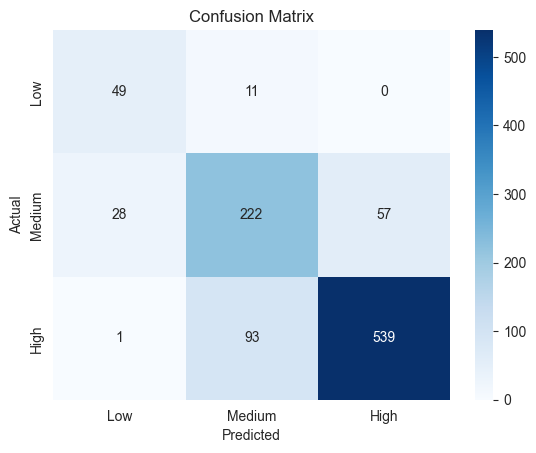

Train accuracy: 0.9275210084033614
Test accuracy: 0.81


In [68]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE, SMOTENC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import pandas as pd

# 1. Separazione delle variabili
X = df1.drop("Traffic_Condition", axis=1)
y = df1["Traffic_Condition"]

# 2. Split: train (60%), val (20%), test (20%)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)


base_model_smote = RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_leaf=5,
                             max_features='sqrt', random_state=42, n_jobs=-1)

# 3. SMOTE prima di RFE alla classe minoritaria
smote = SMOTE(sampling_strategy='not majority', random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# 4. RFE: selezione delle feature migliori (es. top 10) sul dataset bilanciato
rfe = RFE(estimator=base_model_smote, n_features_to_select=10, step=1)
rfe.fit(X_train_res, y_train_res)

selected_features = X.columns[rfe.support_]
print("Feature selezionate:", list(selected_features))

# Applica trasformazione
X_train_rfe = rfe.transform(X_train_res)
X_test_rfe = rfe.transform(X_test) #Problema: Data leakage su test set ⚠️ Applichi una trasformazione "addestrata" su dati mai visti

# 5. Addestramento Random Forest
clf_smote = RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_leaf=5,
                             max_features='sqrt', random_state=42, n_jobs=-1)
#clf_smote.fit(X_train_res, y_train_res)
clf_smote.fit(X_train_rfe, y_train_res)

# 6. Predizione e valutazione
y_pred = clf_smote.predict(X_test_rfe)

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Low", "Medium", "High"]))

# 7. Matrice di confusione
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Low", "Medium", "High"],
            yticklabels=["Low", "Medium", "High"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
print("Train accuracy:", clf_smote.score(X_train_rfe, y_train_res))
print("Test accuracy:", clf_smote.score(X_test_rfe, y_test))


📌 Osservazioni:

Ha migliorato recall e f1-score della classe "Low" rispetto al caso senza SMOTE → 👍

La classe "High" ha ancora la migliore performance (essendo la classe dominante).

Il modello generale è un po’ meno accurato rispetto al caso senza SMOTE, ma è più bilanciato tra le classi → ottimo per problemi sbilanciati.

| Criterio                  | Con SMOTE                                 | Senza SMOTE                    |
| ------------------------- | ----------------------------------------- | ------------------------------ |
| **Accuratezza globale**   | 🔽 leggermente più bassa                  | 🔼 più alta                    |
| **Bilanciamento classi**  | ✅ Migliore                                | ❌ Peggiore (bias verso "High") |
| **Recall su classi rare** | ✅ Migliorato                              | ❌ Più basso (classe "Low")     |
| **Overfitting rischio**   | ⚠️ Leggero aumento (train acc > test acc) | Meno evidente                  |


Possibile spiegazione: ⚠️ Ma X_test non è bilanciato come X_train_res. Quindi:

Le feature che sembravano importanti su X_train_res (dove hai fatto oversampling),

potrebbero non essere altrettanto informative su X_test (che ha la distribuzione originale).

👉 Questo porta a un mismatch semantico, anche se il numero di feature è lo stesso.



# CON PIPELINE

Cross-validation accuracy scores: [0.8175  0.82    0.82125 0.8325  0.83375]
Mean accuracy: 0.825

--- Test Set Classification Report ---
              precision    recall  f1-score   support

         Low       0.68      0.90      0.77        72
      Medium       0.69      0.72      0.71       295
        High       0.91      0.86      0.88       633

    accuracy                           0.82      1000
   macro avg       0.76      0.83      0.79      1000
weighted avg       0.83      0.82      0.82      1000



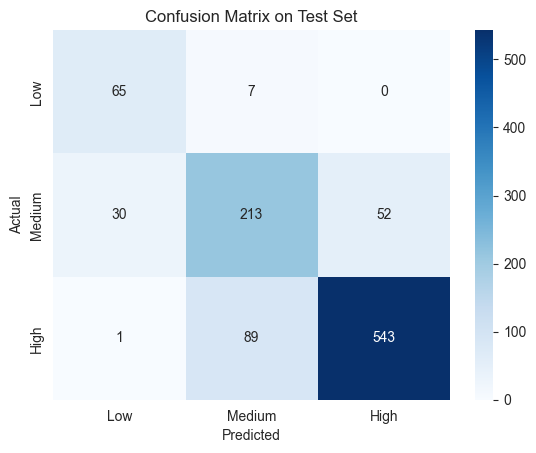

Train accuracy: 0.88775
Test accuracy: 0.821


In [69]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter

# 1. Separazione variabili
X = df1.drop("Traffic_Condition", axis=1)
y = df1["Traffic_Condition"]

# 2. Split test set (20%) - il resto lo useremo per cross-validation (gross-validation)
X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# 3. Pipeline con SMOTE + RFE + Random Forest
base_clf = RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_leaf=5,
                                  max_features='sqrt', random_state=42, n_jobs=-1)

pipeline = ImbPipeline(steps=[
    ('smote', SMOTE(sampling_strategy='not majority', random_state=42)),
    ('rfe', RFE(estimator=base_clf, n_features_to_select=10)),
    ('clf_pipe', base_clf)
])

# 4. Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(pipeline, X_trainval, y_trainval, cv=cv, scoring='accuracy', n_jobs=-1)

print(f"Cross-validation accuracy scores: {scores}")
print(f"Mean accuracy: {scores.mean():.3f}")

# 5. Predizione e valutazione finale sul test set
pipeline.fit(X_trainval, y_trainval)
y_pred = pipeline.predict(X_test)

print("\n--- Test Set Classification Report ---")
print(classification_report(y_test, y_pred, target_names=["Low", "Medium", "High"]))

# 6. Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Low", "Medium", "High"],
            yticklabels=["Low", "Medium", "High"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix on Test Set")
plt.show()

# 7. Train accuracy finale (su tutto il trainval)
print("Train accuracy:", pipeline.score(X_trainval, y_trainval))
print("Test accuracy:", pipeline.score(X_test, y_test))


Tutte le trasformazioni sono concatenate,

La transform() sul test set è coerente con ciò che è stato appreso sul training (anche se SMOTE non si applica lì),

L'ordine è garantito, e non rischi di applicare RFE su dati con una distribuzione diversa.

#### Cross Validation
Questi valori rappresentano l'**accuracy** ottenuta in una validazione incrociata a 5 fold sul training set.
La media (0.825) indica che il modello generalizza bene durante l’addestramento.

#### Classification report sul test set

- **Precision**: delle istanze predette in una certa classe, quante sono corrette.
  (es. precision 0.91 per “High” significa 91% di predizioni corrette per “High”)

- **Recall**: delle istanze reali di una classe, quante sono state correttamente individuate.
  (es. recall 0.90 per “Low” significa 90% delle istanze reali “Low” identificate correttamente)

- **F1-score**: media armonica di precision e recall, misura bilanciata della performance.

- **Support**: numero di esempi reali per ogni classe nel test set.


#### Interpretazione delle classi

- **Classe Low** (minoritaria, 72 esempi):
  - Recall alto (0.90): il modello riconosce bene i casi “Low”.
  - Precision più bassa (0.68): qualche falso positivo, predice “Low” anche per altri casi.

- **Classe Medium** (295 esempi):
  - Metriche più bilanciate ma inferiori (circa 0.7), probabilmente più difficile da distinguere.

- **Classe High** (maggiore nel dataset, 633 esempi):
  - Precision e recall elevate (0.91 e 0.86), il modello la identifica bene.


#### Accuracy generale

- **Train accuracy: 0.88775**
  Il modello è molto preciso sui dati di addestramento.

- **Test accuracy: 0.821**
  Accuracy sul test leggermente più bassa, segno di un moderato overfitting.


#### Conclusioni

- La cross-validation conferma che il modello ha un’accuratezza media di circa l’82-83% su dati non visti.
- L’overfitting è moderato, dato il gap tra train e test accuracy.
- La classe minoritaria (“Low”) viene individuata bene (alta recall), importante in contesti in cui non si vogliono perdere casi rari.
- Possibile margine di miglioramento soprattutto per la classe “Medium” e per ridurre l’overfitting.



Distribuzione classi dopo SMOTE: Counter({2: 2533, 1: 2533, 0: 2533})


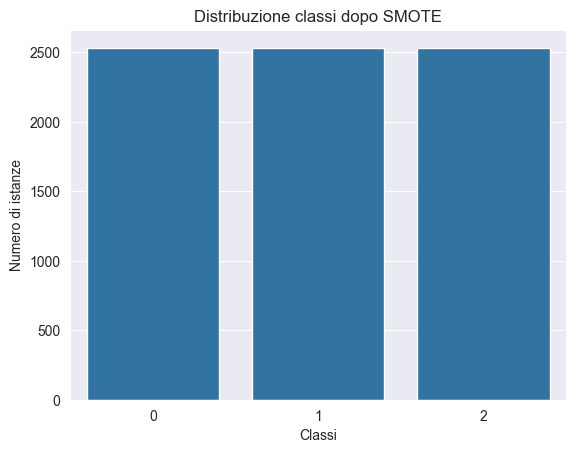

In [70]:
# Visualizza SMOTE
# Applica SMOTE direttamente ai dati di trainval (per analisi della distribuzione)
smote = SMOTE(sampling_strategy='not majority', random_state=42)
X_smote, y_smote = smote.fit_resample(X_trainval, y_trainval)

# Conta le istanze per classe dopo SMOTE
counter = Counter(y_smote)
print("Distribuzione classi dopo SMOTE:", counter)

# Visualizza la distribuzione con un barplot
sns.barplot(x=list(counter.keys()), y=list(counter.values()))
plt.xlabel("Classi")
plt.ylabel("Numero di istanze")
plt.title("Distribuzione classi dopo SMOTE")
plt.show()
